# Explainable AML modeling — simple MVP

This notebook compares **logistic regression, XGBoost, and Explainable Boosting Machine (EBM)** on IBM's synthetic HI-Small transactions. It keeps a reproducible 50% sample for model fitting but uses **all earlier eligible transactions** to build account-history features. It also checks a small set of short-window features, runs three expanding time folds, and shows results and explanations for each model. Run the cells from top to bottom.

This is a class demonstration on **synthetic data**. A high score suggests a transaction for review; it is not a laundering probability or an investigator conclusion. The [project guide](docs/PROJECT_GUIDE.md) explains the choices and limitations. The raw CSV stays local; tables and charts stay in this notebook.

## 1. Imports and settings

Put `HI-Small_Trans.csv` at `data/raw/HI-Small_Trans.csv` as described in the [README](README.md). The seed selects the same 50% rows on repeated runs with the same CSV and row order.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    precision_score, recall_score, f1_score, confusion_matrix,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier, DMatrix
from interpret.glassbox import ExplainableBoostingClassifier

DATA_PATH = Path("data/raw/HI-Small_Trans.csv")
SEED = 42
SAMPLE_FRACTION = 0.50
print("Dataset:", DATA_PATH)
print("Sample fraction:", SAMPLE_FRACTION)

Dataset: data/raw/HI-Small_Trans.csv
Sample fraction: 0.5


## 2. Load a modeling sample and complete earlier history

The CSV has about five million rows. We retain the same seeded 50% modeling sample as before, so the train, validation, and test row counts remain comparable. At the same time, we keep a smaller table of **every transaction before September 11** to calculate past activity. This prevents omitted sample rows from disappearing from an account's history. The unusual September 11–18 tail is excluded from both modeling and history. The label table still compares the full raw file, eligible dates, and modeling sample.

In [2]:
rng = np.random.default_rng(SEED)
sample_parts = []
history_parts = []
raw_rows = raw_positives = eligible_rows = eligible_positives = 0
for chunk in pd.read_csv(
    DATA_PATH,
    chunksize=100_000,
    usecols=["Timestamp", "From Bank", "Account", "To Bank", "Account.1",
             "Amount Received", "Receiving Currency", "Amount Paid",
             "Payment Currency", "Payment Format", "Is Laundering"],
    dtype={"From Bank": str, "Account": str, "To Bank": str, "Account.1": str},
):
    timestamps = pd.to_datetime(chunk["Timestamp"])
    eligible = timestamps < "2022-09-11"
    source_rows = np.arange(raw_rows, raw_rows + len(chunk), dtype=np.int32)
    raw_rows += len(chunk)
    raw_positives += int(chunk["Is Laundering"].sum())
    eligible_rows += int(eligible.sum())
    eligible_positives += int(chunk.loc[eligible, "Is Laundering"].sum())
    keep = eligible & (rng.random(len(chunk)) < SAMPLE_FRACTION)

    sample = chunk.loc[keep].copy()
    sample["source_row"] = source_rows[keep]
    sample_parts.append(sample)

    earlier = chunk.loc[eligible]
    history_parts.append(pd.DataFrame({
        "source_row": source_rows[eligible],
        "timestamp": timestamps.loc[eligible].to_numpy(),
        "sender": earlier["From Bank"] + ":" + earlier["Account"],
        "receiver": earlier["To Bank"] + ":" + earlier["Account.1"],
        "amount_paid": earlier["Amount Paid"].to_numpy(),
        "amount_received": earlier["Amount Received"].to_numpy(),
        "currency": earlier["Payment Currency"].to_numpy(),
        "sampled": keep.loc[eligible].to_numpy(),
    }))

transactions = pd.concat(sample_parts, ignore_index=True).rename(columns={
    "Timestamp": "timestamp", "From Bank": "from_bank",
    "Account": "from_account", "To Bank": "to_bank",
    "Account.1": "to_account", "Amount Received": "amount_received",
    "Receiving Currency": "receiving_currency", "Amount Paid": "amount_paid",
    "Payment Currency": "payment_currency", "Payment Format": "payment_format",
    "Is Laundering": "label",
})
history = pd.concat(history_parts, ignore_index=True)
del sample_parts, history_parts, chunk, earlier, sample

label_balance = pd.DataFrame({
    "population": ["full raw file", "eligible dates", "modeled sample"],
    "rows": [raw_rows, eligible_rows, len(transactions)],
    "positive_labels": [raw_positives, eligible_positives, int(transactions["label"].sum())],
})
label_balance["negative_labels"] = label_balance["rows"] - label_balance["positive_labels"]
label_balance["positive_pct"] = 100 * label_balance["positive_labels"] / label_balance["rows"]
label_balance["negative_pct"] = 100 * label_balance["negative_labels"] / label_balance["rows"]
print(f"Modeling rows: {len(transactions):,}; eligible history rows: {len(history):,}")
display(label_balance.round(4))

Modeling rows: 2,539,464; eligible history rows: 5,077,237


,population,rows,positive_labels,negative_labels,positive_pct,negative_pct
0,full raw file,5078345,5177,5073168,0.1019,99.8981
1,eligible dates,5077237,4522,5072715,0.0891,99.9109
2,modeled sample,2539464,2271,2537193,0.0894,99.9106


## 3. Create features from strictly earlier transactions

For each sender, receiver, and sender–receiver pair, we count transactions **before the current timestamp**. The sender's earlier average payment uses the same currency. We build these features from the full eligible history, then attach them only to the modeling sample. Bank and account IDs are used to connect activity, but are not passed to the models as raw identifiers.

We also calculate **candidate** activity features within fixed six-hour blocks and calendar days: earlier outgoing and incoming counts, amounts, and the sender's earlier incoming amount. They can hint at fan-out, fan-in, and rapid movement. A block is not a rolling six-hour window. We will compare these candidate features on validation before deciding whether to include them in the final model. Transactions with the same timestamp do not count one another.

In [3]:
# Give the same account one numeric ID whether it sends or receives.
accounts = pd.concat([history["sender"], history["receiver"]], ignore_index=True)
account_ids, _ = pd.factorize(accounts, sort=False)
n = len(history)
history["sender_id"] = account_ids[:n].astype(np.int32)
history["receiver_id"] = account_ids[n:].astype(np.int32)
history["currency_id"] = pd.factorize(history["currency"], sort=False)[0].astype(np.int8)
history = history.drop(columns=["sender", "receiver", "currency"])
del accounts, account_ids

history = history.sort_values("timestamp", kind="stable").reset_index(drop=True)
history["block_6h"] = history["timestamp"].dt.floor("6h")
history["day"] = history["timestamp"].dt.floor("D")

# Count only earlier transactions; the subtraction removes simultaneous rows.
for group, name in [
    (["sender_id"], "prior_sender_count"),
    (["receiver_id"], "prior_receiver_count"),
    (["sender_id", "receiver_id"], "prior_pair_count"),
    (["sender_id", "block_6h"], "prior_sender_6h_count"),
    (["receiver_id", "block_6h"], "prior_receiver_6h_count"),
    (["sender_id", "day"], "prior_sender_day_count"),
    (["receiver_id", "day"], "prior_receiver_day_count"),
]:
    history[name] = (
        history.groupby(group, sort=False).cumcount()
        - history.groupby(group + ["timestamp"], sort=False).cumcount()
    ).astype(np.int32)

# Earlier typical payment for this sender and currency.
keys = ["sender_id", "currency_id"]
earlier_amount = (
    history.groupby(keys, sort=False)["amount_paid"].cumsum()
    - history.groupby(keys + ["timestamp"], sort=False)["amount_paid"].cumsum()
)
earlier_count = (
    history.groupby(keys, sort=False).cumcount()
    - history.groupby(keys + ["timestamp"], sort=False).cumcount()
)
history["log_prior_sender_mean_amount"] = np.log1p(
    earlier_amount / earlier_count.replace(0, np.nan)
).fillna(0).astype(np.float32)
del earlier_amount, earlier_count

# Money sent and received earlier in the same six-hour block.
for group, amount, name in [
    (["sender_id", "block_6h"], "amount_paid", "log_prior_sender_6h_amount"),
    (["receiver_id", "block_6h"], "amount_received", "log_prior_receiver_6h_amount"),
]:
    earlier_sum = (
        history.groupby(group, sort=False)[amount].cumsum()
        - history.groupby(group + ["timestamp"], sort=False)[amount].cumsum()
    )
    history[name] = np.log1p(earlier_sum.clip(lower=0)).astype(np.float32)

# For a sampled outgoing transaction, look up what its sender received earlier.
incoming = history.groupby(
    ["receiver_id", "block_6h", "timestamp"], sort=False, as_index=False
)["amount_received"].sum()
incoming = incoming.sort_values("timestamp", kind="stable")
incoming["running_inbound"] = incoming.groupby(
    ["receiver_id", "block_6h"], sort=False
)["amount_received"].cumsum()
outgoing = history.loc[
    history["sampled"], ["source_row", "sender_id", "block_6h", "timestamp"]
].sort_values("timestamp", kind="stable")
incoming = incoming.rename(columns={"receiver_id": "sender_id"})
recent_inbound = pd.merge_asof(
    outgoing, incoming[["sender_id", "block_6h", "timestamp", "running_inbound"]],
    on="timestamp", by=["sender_id", "block_6h"],
    direction="backward", allow_exact_matches=False,
)
recent_inbound["log_prior_sender_inbound_6h_amount"] = np.log1p(
    recent_inbound["running_inbound"].fillna(0)
).astype(np.float32)

history_columns = [
    "prior_sender_count", "prior_receiver_count", "prior_pair_count",
    "log_prior_sender_mean_amount", "prior_sender_6h_count",
    "prior_receiver_6h_count", "prior_sender_day_count",
    "prior_receiver_day_count", "log_prior_sender_6h_amount",
    "log_prior_receiver_6h_amount",
]
prepared = history.loc[
    history["sampled"], ["source_row"] + history_columns
].merge(
    recent_inbound[["source_row", "log_prior_sender_inbound_6h_amount"]],
    on="source_row", how="left",
)
transactions = transactions.merge(prepared, on="source_row", how="left", sort=False)
del history, incoming, outgoing, recent_inbound, prepared, earlier_sum

transactions["timestamp"] = pd.to_datetime(transactions["timestamp"])
transactions = transactions.sort_values("timestamp", kind="stable").reset_index(drop=True)
transactions["log_amount"] = np.log1p(transactions["amount_paid"])
transactions["log_amount_received"] = np.log1p(transactions["amount_received"])
transactions["hour"] = transactions["timestamp"].dt.hour
transactions["same_bank"] = (transactions["from_bank"] == transactions["to_bank"]).astype(int)
transactions["same_account"] = (
    (transactions["from_bank"] == transactions["to_bank"])
    & (transactions["from_account"] == transactions["to_account"])
).astype(int)
print("Full-history feature example:")
display(transactions[["prior_sender_count", "prior_receiver_count",
                      "log_prior_sender_mean_amount", "prior_sender_6h_count",
                      "log_prior_sender_inbound_6h_amount"]].head())

Full-history feature example:


,prior_sender_count,prior_receiver_count,log_prior_sender_mean_amount,prior_sender_6h_count,log_prior_sender_inbound_6h_amount
0,0,0,0.0,0,0.0
1,0,0,0.0,0,0.0
2,0,0,0.0,0,0.0
3,0,0,0.0,0,0.0
4,0,0,0.0,0,0.0


## 4. Split by time and encode categories

Training uses September 1–6 (**64.02%** of modeled rows), validation September 7–8 (**19.00%**), and September 9–10 is the later test/reporting period (**16.98%**). The split dates and sampled modeling rows are unchanged. Each transaction's new history features were computed from transactions strictly earlier than its timestamp, even across split boundaries. Payment format and currencies become numeric indicator columns using training categories only.

The main models use the full-history features. Seven six-hour and calendar-day features remain available as a candidate set for a validation comparison; we do not add them automatically just because they are available.

In [4]:
feature_columns = [
    "log_amount", "log_amount_received", "hour", "same_bank", "same_account",
    "prior_sender_count", "prior_receiver_count", "prior_pair_count",
    "log_prior_sender_mean_amount", "payment_format", "payment_currency",
    "receiving_currency",
]
window_features = [
    "prior_sender_6h_count", "prior_receiver_6h_count",
    "prior_sender_day_count", "prior_receiver_day_count",
    "log_prior_sender_6h_amount", "log_prior_receiver_6h_amount",
    "log_prior_sender_inbound_6h_amount",
]
categories = ["payment_format", "payment_currency", "receiving_currency"]
train = transactions.loc[transactions["timestamp"] < "2022-09-07"].copy()
validation = transactions.loc[
    (transactions["timestamp"] >= "2022-09-07") &
    (transactions["timestamp"] < "2022-09-09")
].copy()
test = transactions.loc[transactions["timestamp"] >= "2022-09-09"].copy()

split_summary = pd.DataFrame({
    "period": ["train", "validation", "test"],
    "rows": [len(train), len(validation), len(test)],
    "positive_labels": [train["label"].sum(), validation["label"].sum(), test["label"].sum()],
})
split_summary["share_of_sample_pct"] = (100 * split_summary["rows"] / len(transactions)).round(2)
split_summary["positive_label_rate_pct"] = (100 * split_summary["positive_labels"] / split_summary["rows"]).round(4)
display(split_summary)

X_train = pd.get_dummies(train[feature_columns], columns=categories, dtype=np.float32).astype(np.float32)
X_validation = pd.get_dummies(validation[feature_columns], columns=categories, dtype=np.float32)
X_test = pd.get_dummies(test[feature_columns], columns=categories, dtype=np.float32)
X_validation = X_validation.reindex(columns=X_train.columns, fill_value=0).astype(np.float32)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0).astype(np.float32)
y_train = train["label"]
y_validation = validation["label"]
y_test = test["label"]
print("Model features:", len(X_train.columns))
display(X_train.head())

,period,rows,positive_labels,share_of_sample_pct,positive_label_rate_pct
0,train,1625750,1260,64.02,0.0775
1,validation,482608,523,19.00,0.1084
2,test,431106,488,16.98,0.1132


Model features: 46


,log_amount,log_amount_received,hour,same_bank,same_account,prior_sender_count,prior_receiver_count,prior_pair_count,log_prior_sender_mean_amount,payment_format_ACH,...,receiving_currency_Mexican Peso,receiving_currency_Ruble,receiving_currency_Rupee,receiving_currency_Saudi Riyal,receiving_currency_Shekel,receiving_currency_Swiss Franc,receiving_currency_UK Pound,receiving_currency_US Dollar,receiving_currency_Yen,receiving_currency_Yuan
0,6.800582,6.800582,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2.424803,2.424803,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2.970927,2.970927,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,5.995357,5.995357,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,9.470613,9.470613,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 5. Define the three models

Logistic regression is the linear baseline. XGBoost learns nonlinear tree patterns. EBM learns interpretable additive effects. All three use a moderate positive-class weight of 10. The earlier inverse-frequency weight was about 1,289 and gave worse validation rankings in exploratory runs. These weights help with rare labels; model scores are still not calibrated probabilities.

In [5]:
positive_weight = 10
models = {
    "Logistic regression": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=500)
    ),
    "XGBoost": XGBClassifier(
        n_estimators=180, max_depth=5, learning_rate=0.06,
        scale_pos_weight=positive_weight, tree_method="hist", n_jobs=4,
        eval_metric="logloss", random_state=SEED,
    ),
    "EBM": ExplainableBoostingClassifier(
        interactions=0, outer_bags=1, max_rounds=200, n_jobs=4, random_state=SEED
    ),
}


## 6. Time-ordered cross-validation inside training

We now **run** three expanding windows: fit on September 1–3 and check September 4; fit on September 1–4 and check September 5; fit on September 1–5 and check September 6. Each fold learns category columns and model weights from its earlier fit rows. Full-history features use only transactions before each row, so later labels and activity cannot enter an earlier row's features. Mean average precision (AP) across these folds selects the model family. September 7–8 remains separate for threshold selection, and September 9–10 is reported afterward. This is time-ordered validation, not stratified K-fold.

In [6]:
fold_rows = []
for name, model in models.items():
    for fit_end, check_end in [
        ("2022-09-04", "2022-09-05"),
        ("2022-09-05", "2022-09-06"),
        ("2022-09-06", "2022-09-07"),
    ]:
        fold_train = train.loc[train["timestamp"] < fit_end]
        fold_check = train.loc[
            (train["timestamp"] >= fit_end) & (train["timestamp"] < check_end)
        ]
        X_fit = pd.get_dummies(
            fold_train[feature_columns], columns=categories, dtype=np.float32
        ).astype(np.float32)
        X_check = pd.get_dummies(
            fold_check[feature_columns], columns=categories, dtype=np.float32
        ).reindex(columns=X_fit.columns, fill_value=0).astype(np.float32)
        y_fit = fold_train["label"]
        weights = np.where(y_fit == 1, positive_weight, 1.0)
        fitted = clone(model)
        if name == "Logistic regression":
            fitted.fit(X_fit, y_fit, logisticregression__sample_weight=weights)
        elif name == "EBM":
            fitted.fit(X_fit, y_fit, sample_weight=weights)
        else:
            fitted.fit(X_fit, y_fit)
        fold_rows.append({
            "model": name,
            "check_day": fit_end,
            "positive_labels": int(fold_check["label"].sum()),
            "average_precision": average_precision_score(
                fold_check["label"], fitted.predict_proba(X_check)[:, 1]
            ),
        })

fold_results = pd.DataFrame(fold_rows)
fold_summary = fold_results.pivot(
    index="model", columns="check_day", values="average_precision"
)
fold_summary["mean_ap"] = fold_summary.mean(axis=1)
fold_summary = fold_summary.sort_values("mean_ap", ascending=False)
selected_model = fold_summary.index[0]
print("Positive labels in the three check days:")
display(fold_results.groupby("check_day")["positive_labels"].first())
print("Average precision by time fold:")
display(fold_summary.round(4))
print("Selected model:", selected_model)

Positive labels in the three check days:


check_day
2022-09-04    196
2022-09-05    235
2022-09-06    258
Name: positive_labels, dtype: int64

Average precision by time fold:


check_day,2022-09-04,2022-09-05,2022-09-06,mean_ap
model,,,,
XGBoost,0.4253,0.4457,0.4562,0.4424
EBM,0.3833,0.4114,0.3908,0.3952
Logistic regression,0.0494,0.0185,0.0313,0.0331


Selected model: XGBoost


## 7. Fit the final models on September 1–6

After the time folds, we fit fresh versions of all three models on **all six training days**. The September 7–8 labels are not used for fitting. Each model still gets a scorecard later in the notebook.

In [7]:
weights = np.where(y_train == 1, positive_weight, 1.0)
models["Logistic regression"].fit(
    X_train, y_train, logisticregression__sample_weight=weights
)
models["XGBoost"].fit(X_train, y_train)
models["EBM"].fit(X_train, y_train, sample_weight=weights)
print("Fitted on all September 1–6 rows:", ", ".join(models))

Fitted on all September 1–6 rows: Logistic regression, XGBoost, EBM


## 8. Choose thresholds and evaluate later activity

**Average precision (AP, a summary of the precision–recall curve)** evaluates ranking across thresholds. For rare labels, the positive-label rate is its random-ranking baseline. **Precision, recall, and F1** evaluate binary alerts at a stated threshold. **False positive rate (FPR)** is false alerts divided by all normal transactions; the confusion matrix gives the counts. The model was selected using the earlier time folds. Logistic regression and EBM use the threshold with the best F1 on September 7–8. To increase detection while keeping a majority of alerts useful, XGBoost uses the validation threshold with the **highest recall among thresholds with at least 70% precision**. We also show its F1-optimal and 40%-precision alternatives as tradeoffs. Every threshold is chosen on September 7–8 and then applied unchanged to September 9–10.

The **illustrative class-project goal**, set before evaluating this revised feature on September 9–10, is at least **30% precision, 30% recall, 0.30 F1**, and **FPR below 0.1%**. These values are not regulatory or industry minimums. Precision and recall are explicitly discussed in industry AML guidance; F1, FPR, and AP are useful statistical measures for this labeled experiment. Actual risk coverage and SAR quality cannot be measured from this CSV. A bank would set outcomes against its own risk coverage, investigation capacity, and alert quality. The [Wolfsberg Group](https://wolfsberg-group.org/resources/195/202) recommends considering precision, recall, priority-risk coverage, and SAR quality; the [FFIEC manual](https://bsaaml.ffiec.gov/manual/AssessingComplianceWithBSARegulatoryRequirements/04) describes risk-based monitoring and review rather than numeric model cutoffs.

In [8]:
rows = []
scores = {}
thresholds = {}
f1_thresholds = {}
for name, model in models.items():
    validation_score = model.predict_proba(X_validation)[:, 1]
    precision_curve, recall_curve, cutoff_values = precision_recall_curve(
        y_validation, validation_score
    )
    f1_curve = (
        2 * precision_curve[:-1] * recall_curve[:-1]
        / (precision_curve[:-1] + recall_curve[:-1] + 1e-12)
    )
    f1_thresholds[name] = cutoff_values[np.argmax(f1_curve)]
    if name == "XGBoost":
        high_precision = np.where(precision_curve[:-1] >= 0.70)[0]
        thresholds[name] = cutoff_values[high_precision[np.argmax(recall_curve[high_precision])]]
    else:
        thresholds[name] = f1_thresholds[name]

    for period, X, y in [
        ("validation", X_validation, y_validation),
        ("test", X_test, y_test),
    ]:
        score = validation_score if period == "validation" else model.predict_proba(X)[:, 1]
        scores[(name, period)] = score
        alerts = score >= thresholds[name]
        tn, fp, fn, tp = confusion_matrix(y, alerts).ravel()
        rows.append({
            "model": name,
            "period": period,
            "average_precision": average_precision_score(y, score),
            "precision": precision_score(y, alerts, zero_division=0),
            "recall": recall_score(y, alerts),
            "f1": f1_score(y, alerts),
            "false_positive_rate": fp / (fp + tn),
            "true_positives": int(tp),
            "false_positives": int(fp),
            "alerts": int(alerts.sum()),
        })
results = pd.DataFrame(rows)
print("Selected using time-fold mean AP:", selected_model)
print("Positive-label rate: validation", round(y_validation.mean(), 4),
      "reporting period", round(y_test.mean(), 4))
display(results.round(4))
selected_alerts = scores[(selected_model, "test")] >= thresholds[selected_model]
print("Validation-selected threshold for", selected_model, ":", round(thresholds[selected_model], 4))
display(pd.DataFrame(
    confusion_matrix(y_test, selected_alerts),
    index=["actual normal", "actual laundering"],
    columns=["no alert", "alert"],
))

later = results[(results["model"] == selected_model) & (results["period"] == "test")].iloc[0]
print("Illustrative class-project goal on the later period:")
for metric, target in [("precision", 0.30), ("recall", 0.30), ("f1", 0.30)]:
    print(f"{metric}: {later[metric]:.2%} (goal at least {target:.0%}) —",
          "met" if later[metric] >= target else "not met")
print(f"false positive rate: {later['false_positive_rate']:.3%} (goal below 0.1%) —",
      "met" if later["false_positive_rate"] < 0.001 else "not met")

# The same XGBoost ranking can produce more recall by reviewing more alerts.
xgb_p, xgb_r, xgb_cutoffs = precision_recall_curve(
    y_validation, scores[("XGBoost", "validation")]
)
forty_percent = np.where(xgb_p[:-1] >= 0.40)[0]
forty_threshold = xgb_cutoffs[forty_percent[np.argmax(xgb_r[forty_percent])]]
threshold_options = [
    ("Best validation F1", f1_thresholds["XGBoost"]),
    ("At least 70% validation precision (chosen)", thresholds["XGBoost"]),
    ("At least 40% validation precision", forty_threshold),
]
tradeoff_rows = []
for policy, threshold in threshold_options:
    for period, y, score in [
        ("validation", y_validation, scores[("XGBoost", "validation")]),
        ("test", y_test, scores[("XGBoost", "test")]),
    ]:
        alerts = score >= threshold
        tn, fp, fn, tp = confusion_matrix(y, alerts).ravel()
        tradeoff_rows.append({
            "policy": policy, "period": period, "threshold": threshold,
            "precision": tp / (tp + fp), "recall": tp / (tp + fn),
            "f1": 2 * tp / (2 * tp + fp + fn),
            "false_positive_rate": fp / (fp + tn),
            "alerts": int(tp + fp), "true_positives": int(tp),
            "false_positives": int(fp),
        })
print("XGBoost recall versus alert workload (all choices use validation only):")
display(pd.DataFrame(tradeoff_rows).round(4))

top = np.argsort(-scores[(selected_model, "test")])[:10]
top_transactions = test.iloc[top][[
    "timestamp", "amount_paid", "payment_currency", "amount_received",
    "receiving_currency", "payment_format", "label"
]].copy()
top_transactions["model_score"] = scores[(selected_model, "test")][top]
print("Highest-scored reporting-period transactions (examples, not a metric):")
display(top_transactions)

Selected using time-fold mean AP: XGBoost
Positive-label rate: validation 0.0011 reporting period 0.0011


,model,period,average_precision,precision,recall,f1,false_positive_rate,true_positives,false_positives,alerts
0,Logistic regression,validation,0.0350,0.0480,0.5105,0.0878,0.0110,267,5295,5562
1,Logistic regression,test,0.0196,0.0275,0.5164,0.0523,0.0207,252,8902,9154
2,XGBoost,validation,0.5196,0.7000,0.4417,0.5416,0.0002,231,99,330
3,XGBoost,test,0.4640,0.6147,0.4119,0.4933,0.0003,201,126,327
4,EBM,validation,0.4375,0.8372,0.3442,0.4878,0.0001,180,35,215
5,EBM,test,0.3976,0.8114,0.2910,0.4284,0.0001,142,33,175


Validation-selected threshold for XGBoost : 0.471


,no alert,alert
actual normal,430492,126
actual laundering,287,201


Illustrative class-project goal on the later period:
precision: 61.47% (goal at least 30%) — met
recall: 41.19% (goal at least 30%) — met
f1: 49.33% (goal at least 30%) — met
false positive rate: 0.029% (goal below 0.1%) — met
XGBoost recall versus alert workload (all choices use validation only):


,policy,period,threshold,precision,recall,f1,false_positive_rate,alerts,true_positives,false_positives
0,Best validation F1,validation,0.5758,0.8431,0.4111,0.5527,0.0001,255,215,40
1,Best validation F1,test,0.5758,0.7364,0.3607,0.4842,0.0001,239,176,63
2,At least 70% validation precision (chosen),validation,0.4710,0.7000,0.4417,0.5416,0.0002,330,231,99
3,At least 70% validation precision (chosen),test,0.4710,0.6147,0.4119,0.4933,0.0003,327,201,126
4,At least 40% validation precision,validation,0.3614,0.4003,0.5143,0.4502,0.0008,672,269,403
5,At least 40% validation precision,test,0.3614,0.3526,0.4754,0.4049,0.0010,658,232,426


Highest-scored reporting-period transactions (examples, not a metric):


,timestamp,amount_paid,payment_currency,amount_received,receiving_currency,payment_format,label,model_score
2280233,2022-09-09 12:19:00,15864.02,Euro,15864.02,Euro,ACH,1,0.998943
2272285,2022-09-09 11:43:00,16399.75,US Dollar,16399.75,US Dollar,ACH,1,0.997541
2474915,2022-09-10 07:53:00,7731.45,US Dollar,7731.45,US Dollar,ACH,1,0.997355
2377453,2022-09-09 19:36:00,18231.82,US Dollar,18231.82,US Dollar,ACH,1,0.996655
2224533,2022-09-09 08:10:00,11249.63,UK Pound,11249.63,UK Pound,ACH,1,0.995765
2470253,2022-09-10 06:45:00,14816.42,US Dollar,14816.42,US Dollar,ACH,1,0.995680
2491280,2022-09-10 11:54:00,9968.97,Euro,9968.97,Euro,ACH,1,0.994959
2501754,2022-09-10 14:34:00,5770.40,US Dollar,5770.40,US Dollar,ACH,1,0.994868
2488575,2022-09-10 11:13:00,15194.76,US Dollar,15194.76,US Dollar,ACH,1,0.994483
2493131,2022-09-10 12:21:00,6889.99,US Dollar,6889.99,US Dollar,ACH,1,0.994436


### 8.1 Did the short-window candidate features help?

The main XGBoost model uses complete earlier history. Here we fit one extra XGBoost model with seven fixed six-hour and calendar-day features. Both versions use the **same recall-oriented threshold rule**: maximize validation recall while keeping validation precision at or above 70%. The candidate has lower validation AP, recall, and F1, so the final models leave these features out. September 9–10 is shown as an exploratory check; extra features are not automatically better.

In [9]:
candidate_columns = feature_columns + window_features
X_train_window = pd.get_dummies(
    train[candidate_columns], columns=categories, dtype=np.float32
).astype(np.float32)
X_validation_window = pd.get_dummies(
    validation[candidate_columns], columns=categories, dtype=np.float32
).reindex(columns=X_train_window.columns, fill_value=0).astype(np.float32)
X_test_window = pd.get_dummies(
    test[candidate_columns], columns=categories, dtype=np.float32
).reindex(columns=X_train_window.columns, fill_value=0).astype(np.float32)
window_model = clone(models["XGBoost"])
window_model.fit(X_train_window, y_train)
window_validation_score = window_model.predict_proba(X_validation_window)[:, 1]
window_test_score = window_model.predict_proba(X_test_window)[:, 1]
p, r, cutoffs = precision_recall_curve(y_validation, window_validation_score)
high_precision = np.where(p[:-1] >= 0.70)[0]
window_threshold = cutoffs[high_precision[np.argmax(r[high_precision])]]
window_rows = []
for period, y, score in [
    ("validation", y_validation, window_validation_score),
    ("test", y_test, window_test_score),
]:
    alerts = score >= window_threshold
    tn, fp, fn, tp = confusion_matrix(y, alerts).ravel()
    window_rows.append({
        "features": "plus short-window candidates", "period": period,
        "average_precision": average_precision_score(y, score),
        "precision": precision_score(y, alerts, zero_division=0),
        "recall": recall_score(y, alerts), "f1": f1_score(y, alerts),
        "false_positive_rate": fp / (fp + tn), "alerts": int(alerts.sum()),
    })
base_rows = results.loc[results["model"] == "XGBoost", [
    "period", "average_precision", "precision", "recall", "f1",
    "false_positive_rate", "alerts",
]].copy()
base_rows.insert(0, "features", "complete earlier history")
display(pd.concat([base_rows, pd.DataFrame(window_rows)], ignore_index=True).round(4))

,features,period,average_precision,precision,recall,f1,false_positive_rate,alerts
0,complete earlier history,validation,0.5196,0.7000,0.4417,0.5416,0.0002,330
1,complete earlier history,test,0.4640,0.6147,0.4119,0.4933,0.0003,327
2,plus short-window candidates,validation,0.5158,0.7000,0.4149,0.5210,0.0002,310
3,plus short-window candidates,test,0.4625,0.5414,0.4016,0.4612,0.0004,362


### 8.2 Where does the selected model miss positive labels?

These tables show the selected model's alert quality by payment format and day. Small groups have uncertain rates, so focus on the positive and alert counts. We inspect the later period to understand limitations; we do not use it to choose the model or threshold.

In [10]:
format_rows = []
day_rows = []
for period, frame, score, threshold in [
    ("validation", validation, scores[(selected_model, "validation")], thresholds[selected_model]),
    ("test", test, scores[(selected_model, "test")], thresholds[selected_model]),
]:
    review = frame[["timestamp", "payment_format", "label"]].copy()
    review["alert"] = score >= threshold
    review["caught"] = (review["label"] == 1) & review["alert"]
    review["false_alert"] = (review["label"] == 0) & review["alert"]
    review["day"] = review["timestamp"].dt.date
    by_format = review.groupby("payment_format").agg(
        rows=("label", "size"), positive_labels=("label", "sum"),
        caught=("caught", "sum"), false_alerts=("false_alert", "sum"),
    ).reset_index()
    by_format["period"] = period
    by_format["recall"] = by_format["caught"] / by_format["positive_labels"].replace(0, np.nan)
    format_rows.append(by_format)
    by_day = review.groupby("day").agg(
        rows=("label", "size"), positive_labels=("label", "sum"),
        caught=("caught", "sum"), false_alerts=("false_alert", "sum"),
    ).reset_index()
    by_day["period"] = period
    by_day["precision"] = by_day["caught"] / (by_day["caught"] + by_day["false_alerts"])
    by_day["recall"] = by_day["caught"] / by_day["positive_labels"]
    day_rows.append(by_day)
print("Selected-model detection by payment format:")
display(pd.concat(format_rows, ignore_index=True).round(4))
print("Selected-model alert quality by day:")
display(pd.concat(day_rows, ignore_index=True).round(4))

Selected-model detection by payment format:


,payment_format,rows,positive_labels,caught,false_alerts,period,recall
0,ACH,58481,447,231,99,validation,0.5168
1,Bitcoin,14484,10,0,0,validation,0.0000
2,Cash,51592,10,0,0,validation,0.0000
3,Cheque,198008,31,0,0,validation,0.0000
4,Credit Card,141666,25,0,0,validation,0.0000
5,Wire,18377,0,0,0,validation,NaN
6,ACH,59616,428,201,126,test,0.4696
7,Bitcoin,12167,6,0,0,test,0.0000
8,Cash,45985,7,0,0,test,0.0000
9,Cheque,173351,29,0,0,test,0.0000


Selected-model alert quality by day:


,day,rows,positive_labels,caught,false_alerts,period,precision,recall
0,2022-09-07,241805,258,121,49,validation,0.7118,0.4690
1,2022-09-08,240803,265,110,50,validation,0.6875,0.4151
2,2022-09-09,327238,263,104,70,test,0.5977,0.3954
3,2022-09-10,103868,225,97,56,test,0.6340,0.4311


## 9. Results and explanation for each model

Each scorecard below has **its own table and four-panel chart** comparing validation with the later test period: precision, recall, F1, and false positive rate (FPR). The first three panels use a 0–100% scale; FPR has its own smaller scale so the difference remains readable. **Higher** precision, recall, and F1 are better; **lower** FPR is better. Average precision (AP) and alert counts appear in each table. These are evaluation measures for this synthetic exercise, not regulator-set targets.

The model was selected on the three earlier time folds; thresholds were chosen on September 7–8. Read the later test bars as the more useful comparison, while remembering that this period was examined during earlier project revisions.

In [11]:
def show_model_scorecard(name):
    model_results = results[results["model"] == name].set_index("period").loc[["validation", "test"]]
    print(name, "— validation-selected threshold:", round(thresholds[name], 4))
    display(model_results[["average_precision", "precision", "recall", "f1",
                           "false_positive_rate", "alerts", "true_positives",
                           "false_positives"]].round(4))

    metrics = [
        ("precision", "Precision"),
        ("recall", "Recall"),
        ("f1", "F1"),
        ("false_positive_rate", "False positive rate"),
    ]
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    for ax, (metric, title) in zip(axes, metrics):
        values = model_results[metric].to_numpy()
        bars = ax.bar(["Validation", "Test"], values, color=["#4477AA", "#EE8866"])
        labels = [f"{value:.3%}" if metric == "false_positive_rate" else f"{value:.1%}"
                  for value in values]
        ax.bar_label(bars, labels=labels, padding=3, fontsize=9)
        ax.set_title(title)
        ax.set_ylim(0, max(values) * 1.35 if metric == "false_positive_rate" else 1)
        ax.yaxis.set_major_formatter(
            PercentFormatter(1, decimals=3 if metric == "false_positive_rate" else 0)
        )
        ax.tick_params(axis="x", labelrotation=25)
    fig.suptitle(name + ": validation vs later test", fontsize=14)
    fig.tight_layout()
    plt.show()

### 9.1 Logistic regression

The linear baseline catches **252 of 488** positive later-period labels (**51.6% recall**), but raises **9,154 alerts** with **8,902 false positives**. Its **2.75% precision**, **0.052 F1**, and **2.067% FPR** imply a large review workload for this sample. The coefficients below show which encoded features push its score up or down; they are not causal explanations.

Logistic regression — validation-selected threshold: 0.1213


,average_precision,precision,recall,f1,false_positive_rate,alerts,true_positives,false_positives
period,,,,,,,,
validation,0.0350,0.0480,0.5105,0.0878,0.0110,5562,267,5295
test,0.0196,0.0275,0.5164,0.0523,0.0207,9154,252,8902


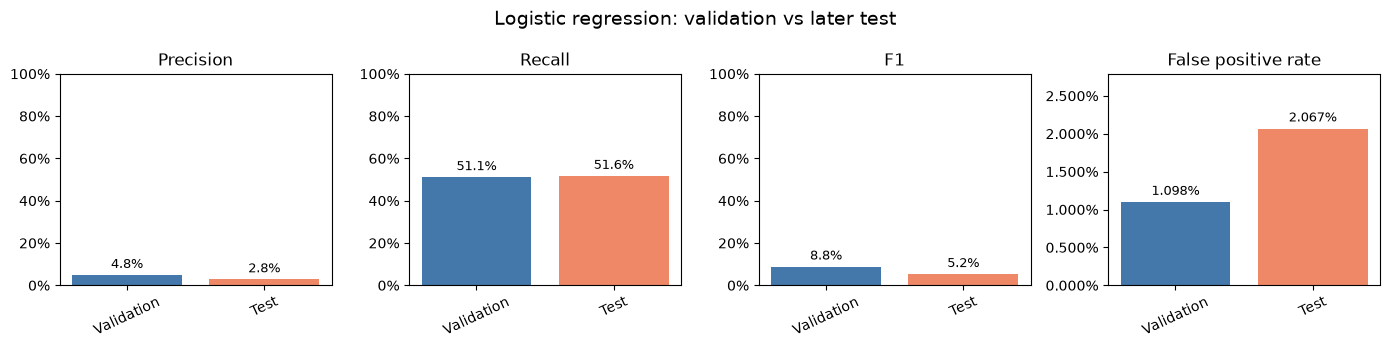

Largest logistic coefficients by absolute size:


prior_pair_count              -1.926764
payment_format_ACH             1.063007
same_account                  -0.773964
prior_sender_count             0.647344
same_bank                     -0.366959
payment_format_Wire           -0.332183
payment_format_Reinvestment   -0.328874
payment_format_Cheque         -0.251018
log_amount                     0.222599
log_amount_received            0.189133
dtype: float32

In [12]:
show_model_scorecard("Logistic regression")

logistic = models["Logistic regression"].named_steps["logisticregression"]
coefficients = pd.Series(logistic.coef_[0], index=X_train.columns)
print("Largest logistic coefficients by absolute size:")
display(coefficients.reindex(coefficients.abs().sort_values(ascending=False).index).head(10))

### 9.2 XGBoost

XGBoost has the highest mean time-fold AP, so it is the selected model. We use the threshold that gives the highest September 7–8 recall while keeping validation precision at least **70%**. On September 9–10 it finds **201 of 488** positive labels in **327 alerts**: **61.5% precision**, **41.2% recall**, **0.493 F1**, and **0.0293% FPR**. Compared with the previous XGBoost version, that is **23 more positives found**, but also **71 more false alerts**. The F1 score stays about the same. All four illustrative classroom goals are met, but **287** positives are still missed. The payment-format table above shows that **all 201 caught positives are ACH**; it catches **none of 60 positive non-ACH payments**. The Tree SHAP values below explain **one high-scored row** in raw model-score units; they do not prove laundering.

XGBoost — validation-selected threshold: 0.471


,average_precision,precision,recall,f1,false_positive_rate,alerts,true_positives,false_positives
period,,,,,,,,
validation,0.5196,0.7000,0.4417,0.5416,0.0002,330,231,99
test,0.4640,0.6147,0.4119,0.4933,0.0003,327,201,126


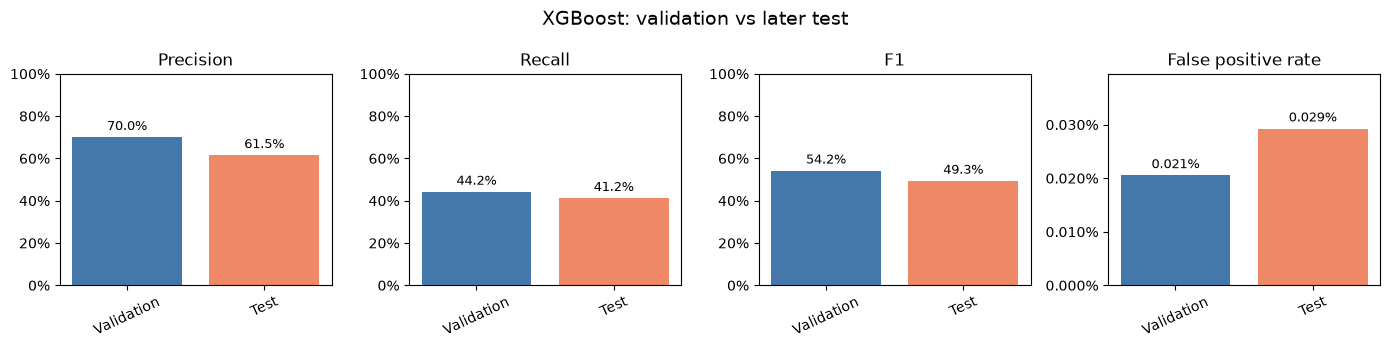

Largest Tree SHAP contributions for one high-scored test row:


payment_format_ACH              4.802896
log_prior_sender_mean_amount    2.003573
prior_sender_count              1.722065
prior_pair_count                1.470546
log_amount                      0.591491
prior_receiver_count            0.440452
log_amount_received             0.408563
receiving_currency_Euro         0.263410
payment_currency_Euro           0.230730
hour                            0.156627
dtype: float32

In [13]:
show_model_scorecard("XGBoost")

xgboost = models["XGBoost"]
most_flagged = np.argmax(scores[("XGBoost", "test")])
contributions = xgboost.get_booster().predict(
    DMatrix(X_test.iloc[[most_flagged]]), pred_contribs=True
)[0][:-1]
shap_values = pd.Series(contributions, index=X_train.columns)
print("Largest Tree SHAP contributions for one high-scored test row:")
display(shap_values.reindex(shap_values.abs().sort_values(ascending=False).index).head(10))

### 9.3 Explainable Boosting Machine (EBM)

EBM raises **175 later-period alerts** with **142 true positives** and **33 false positives**. Its **81.1% precision** and **0.0077% FPR** are stronger than XGBoost's, while its **29.1% recall** misses more known positives; **F1 is 0.428**. This is a different precision–recall tradeoff. EBM's term importances below summarize global model influence; they do not explain a specific transaction.

EBM — validation-selected threshold: 0.5785


,average_precision,precision,recall,f1,false_positive_rate,alerts,true_positives,false_positives
period,,,,,,,,
validation,0.4375,0.8372,0.3442,0.4878,0.0001,215,180,35
test,0.3976,0.8114,0.2910,0.4284,0.0001,175,142,33


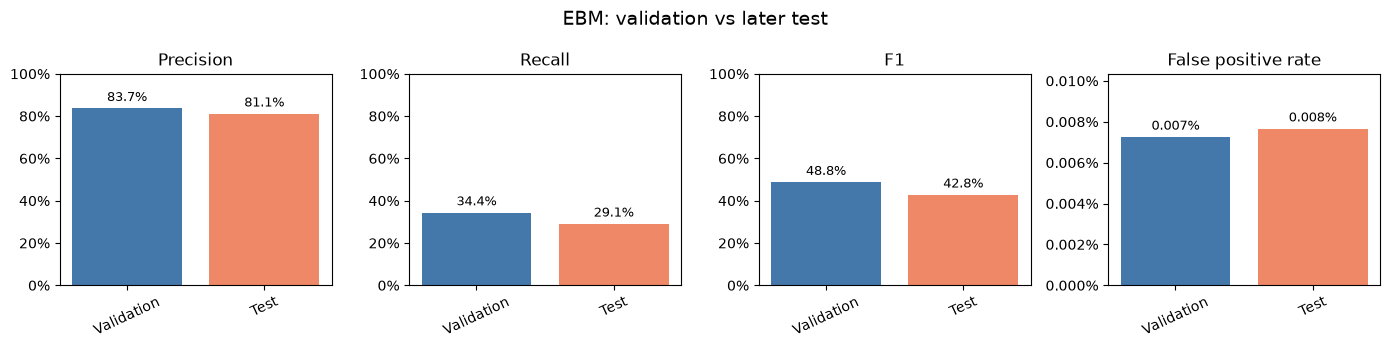

Most important EBM terms overall:


prior_sender_count              1.178605
prior_pair_count                1.165278
log_prior_sender_mean_amount    1.024143
payment_format_ACH              0.750426
payment_format_Cheque           0.429803
prior_receiver_count            0.344063
payment_format_Credit Card      0.337292
same_account                    0.311897
payment_format_Reinvestment     0.296828
same_bank                       0.233128
dtype: float64

In [14]:
show_model_scorecard("EBM")

ebm = models["EBM"]
ebm_terms = pd.Series(ebm.term_importances(), index=ebm.term_names_)
print("Most important EBM terms overall:")
display(ebm_terms.sort_values(ascending=False).head(10))

## 10. What this MVP can claim

This notebook demonstrates a **time-based comparison of three models on a 50% sample of synthetic transactions**, with three expanding validation folds inside September 1–6. History features use **all earlier eligible transactions**, including rows outside the modeling sample. Account and bank IDs help build those features but are not direct predictors. These features capture part of the transaction network, though they do not reproduce the richer graph modeling in the [original IBM study](https://papers.nips.cc/paper/2023/file/5f38404edff6f3f642d6fa5892479c42-Paper-Datasets_and_Benchmarks.pdf). Its published F1 values use a different feature pipeline and split and are not directly comparable.

A deeper XGBoost model improved validation average precision from **0.4781 to 0.5196** using the same full-history inputs. Its selected threshold prioritizes recall while requiring at least **70% precision on validation**. On September 9–10, it catches **201 of 488** positive labels in **327 alerts**, with **61.5% precision**, **41.2% recall**, **0.493 F1**, and **0.0293% FPR**. This is 23 more positives and 71 more false alerts than the earlier F1-threshold version. The notebook shows the F1-optimal and more aggressive 40%-precision alternatives so the alert workload is visible. Seven candidate six-hour and calendar-day activity features lowered validation AP, recall, and F1 under the same threshold policy, so they remain a comparison rather than final inputs.

All four overall classroom goals are met. Yet the selected model catches **none of 60 positive non-ACH payments** in the reporting period, an important gap hidden by aggregate metrics. The September 11–18 data has a sharp volume and label-rate shift and is excluded. We examined September 9–10 while developing the project, so these results are **exploratory**, not an untouched final estimate. Scores are **not calibrated probabilities**. The CSV has no investigator decisions or SAR outcomes, so it cannot evaluate those outcomes.

### How this relates to bank AML monitoring

Banks may combine transaction reports, rules, intelligent surveillance, and referrals to create alerts. Investigators examine customer and transaction context before deciding whether activity warrants a Suspicious Activity Report. The [FFIEC BSA/AML Examination Manual](https://bsaaml.ffiec.gov/manual/AssessingComplianceWithBSARegulatoryRequirements/04) describes these steps and notes that monitoring depends on each bank's risks. The [2026 interagency model-risk guidance](https://www.federalreserve.gov/supervisionreg/srletters/SR2602a1.pdf) discusses testing aligned with model purpose and ongoing monitoring; it does not prescribe a universal AML classifier threshold or a fixed number of features. Our three-model comparison covers model scoring and synthetic-label alerts only. The numerical goals above are classroom benchmarks, not evidence that a model is ready for a bank.